# Применение МО для нормирования ТЭР
Методы машинного обучения для осуществления нормирования топливно-энергетических ресурсов, расходуемых на нужды восстановительных поездов на основании анализа исторических данных

## Подключение модулей и библиотек:

In [ ]:
!pip3 install phik

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 7.9 MB/s eta 0:00:00


In [ ]:
!pip3 install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 6.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
from scipy import stats

from tqdm import tqdm

from phik import phik_matrix
from phik.report import plot_correlation_matrix

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, make_scorer, classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, recall_score, precision_score,f1_score, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_predict,cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from google.colab import files
from IPython.display import Image

import warnings
warnings.filterwarnings('ignore')

## Загрузка исходных данных
Загрузим таблицу данных о движении хозяйственные поездов с локомотивной тягой, группа 8001-8048 (восстановительные) за 5-лет: 2018-2022

In [ ]:
fuel = pd.read_csv('/content/8001-date.csv', sep=';', decimal=',')
fuel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657 entries, 0 to 1656
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data                   1656 non-null   object 
 1   customer               1654 non-null   object 
 2   source_financing       1654 non-null   object 
 3   type_work              1654 non-null   object 
 4   series                 1656 non-null   object 
 5   movement_clock         1655 non-null   float64
 6   maneuvers_clock        1656 non-null   float64
 7   with_brigade_clock     1656 non-null   float64
 8   without_brigade_clock  1656 non-null   float64
 9   crew_work_clock        1656 non-null   float64
 10  total_clock            1656 non-null   float64
 11  mileage_linear         1656 non-null   float64
 12  total_mileage          1656 non-null   float64
 13  gross_work             1656 non-null   float64
 14  fuel_normal            1656 non-null   float64
 15  fuel

## Выполним визуальный осмотр данных

In [ ]:
fuel.head(2)

,data,customer,source_financing,type_work,series,movement_clock,maneuvers_clock,with_brigade_clock,without_brigade_clock,crew_work_clock,total_clock,mileage_linear,total_mileage,gross_work,fuel_normal,fuel_fact
0,2018-01-01,VP-1,traffic,planned,550-2TE10U,2.0,0.0,1.2,0.0,3.4,3.2,0.0,1.2,72.5,367.8,367.8
1,2018-01-01,VP-10,traffic,planned,575-2TE10M,0.5,0.0,2.9,0.0,13.8,3.4,0.0,2.9,16.7,50.1,103.1


In [ ]:
fuel['fuel_fact'].mean()

395.6884615384616

## Описание признаков

**Серия** - series <br>
**Заказчик** - customer<br>
**Источник финансирования** – source_financing:<br>
- Перевозки – traffic;
- Инвестиции – investments;
- Прочее – other.

**Вид работы** – type_work:<br>

- Работа по диагностике – diagnostic;
- Восст. и пож. поезда (плановые) – planned;
- Восст. и пож. поезда (внеплановые) – unscheduled;
- Содержание и ремонт инфраструктуры – repair;
- Работа со снегоочистителями – snow_clearing;
- Сплотки рез-х лок-в на хоз. работах – locomotive_rafts;
- Передисл. пасс. вагонов - relocation_cars;
- Работа резервных лок-в и толкачей - reserve_locomotives;
- Перевозка к месту раб. по инфрастр. - transportation_location

**Работа в движении, локомотиво-часы:** movement_clock

**Работа в маневрах, локомотиво-часы:** maneuvers_clock

**Простои с бригадой:** with_brigade_clock

**Простои без бригады:** without_brigade_clock

**Работа бригады:** crew_work_clock

**Всего:** total_clock

**Пробег линейный, км:** mileage_linear

**Общий пробег, км:** total_mileage

**Работа брутто, 10^3 ткм:** gross_work

**Расход топлива, норма:** fuel_normal

**Расход топлива, факт:** fuel_fact

# Исследовательский анализ данных

## Удалим строки с пропусками

Существует стратегия замены пропусков в категориях на
"unknown", но в нашем случае данная стратегия неэффективна, так рассеивает какую-то категорию.

In [ ]:
# Вывести строки с пропусками

# fuel_null = fuel[fuel.isnull().any(axis=1)]
# fuel_null

In [ ]:
# Удалим строку 1656

# fuel = fuel.drop(index=1656)

In [ ]:
# Заменим пропуски в категориях на "unknown", в цифровых данных на 0

# fuel[['customer', 'source_financing', 'type_work']] = fuel[['customer', 'source_financing', 'type_work']].fillna("unknown")
# fuel[['movement_clock']] = fuel[['movement_clock']].fillna(0)

In [ ]:
# Посчитать количество строк с пропусками

fuel.isnull().sum().sum()

23

In [ ]:
# Удалить пропуски

fuel = fuel.dropna()

## Выделим месяц работы локомотива

Так как год всегда будет разным, и модель не будет использовать данные о дате при предсказании более поздних событий, то есть смысл выделить из даты формата ГГГГ-ММ-ДД – месяц события.

In [ ]:
# Исправим формат данных с object на datetime64

fuel['data']= pd.to_datetime(fuel['data'])
fuel['data_month'] = fuel['data'].dt.month.astype('object')

In [ ]:
# Оценим загрузку хозяйственных поездов по месяцам года

fuel['data_month'].value_counts()

data_month
3     283
8     189
4     153
9     141
10    130
2     126
6     125
7     122
12    116
5     113
11     96
1      59
Name: count, dtype: int64

Вывод: Максимально загруженный месяц - март.


## Оценим потребление топлива на километр в зависимости от месяца

In [ ]:
# Количество нулевых значений в общем пробеге

seasonal_fuel = fuel.copy()
seasonal_fuel[seasonal_fuel['total_mileage'] == 0].shape

(14, 17)

In [ ]:
# удалим нулевые значения в total_mileage, чтобы оценить параметр - затраты топлива на километр

seasonal_fuel = seasonal_fuel.loc[~(seasonal_fuel['total_mileage']==0)]

In [ ]:
# добавим столбец затраты на километр

seasonal_fuel['consumption_km'] = seasonal_fuel['fuel_fact']/seasonal_fuel['total_mileage']
seasonal_fuel = seasonal_fuel[['data_month', 'series', 'customer', 'total_mileage', 'fuel_fact', 'consumption_km']]
seasonal_fuel.head(3)

,data_month,series,customer,total_mileage,fuel_fact,consumption_km
0,1,550-2TE10U,VP-1,1.2,367.8,306.500000
1,1,575-2TE10M,VP-10,2.9,103.1,35.551724
2,1,543-TEM2,VP-14,8.2,113.0,13.780488


### Потребление топлива на километр в зависимости от месяца

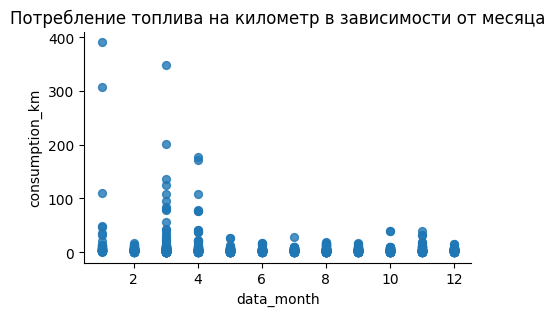

In [ ]:
from matplotlib import pyplot as plt
seasonal_fuel.plot(kind='scatter', x='data_month', y='consumption_km', s=32, alpha=.8, figsize = (5, 3))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Потребление топлива на километр в зависимости от месяца');

Наблюдается сезонное увеличение потребления энергии на километр

###  Потребление топлива на километр в зависимости от общего расхода

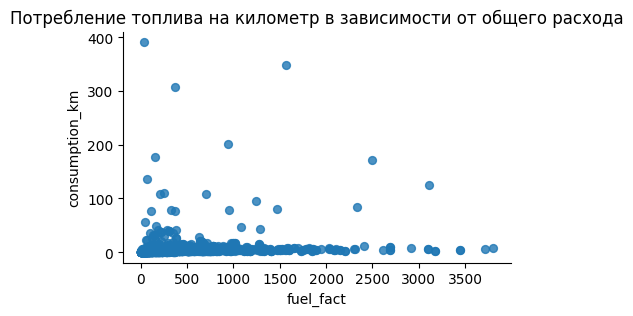

In [ ]:
from matplotlib import pyplot as plt
seasonal_fuel.plot(kind='scatter', x='fuel_fact', y='consumption_km', s=32, alpha=.8, figsize = (5, 3))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Потребление топлива на километр в зависимости от общего расхода');

### Распределения затрат топлива от общего пробега

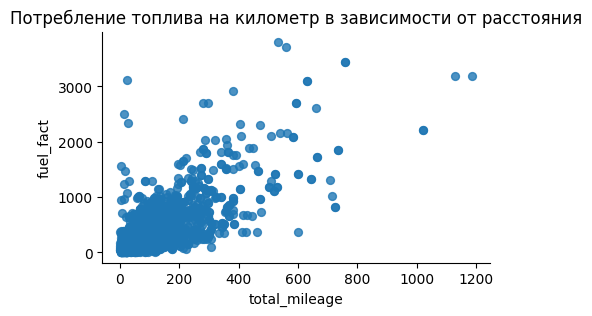

In [ ]:
from matplotlib import pyplot as plt
seasonal_fuel.plot(kind='scatter', x='total_mileage', y='fuel_fact', s=32, alpha=.8, figsize = (5, 3))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.title('Потребление топлива на километр в зависимости от расстояния');

Данный график иллюстрирует высокую степень рассеяния потребления топлива в зависимости от общего пробега.

Наблюдаются выбросы по потреблению топлива на километр, удалять их нельзя, так как это может быть результат хозяйственной деятельности.

### Сравнение потребления топлива по локомотивам

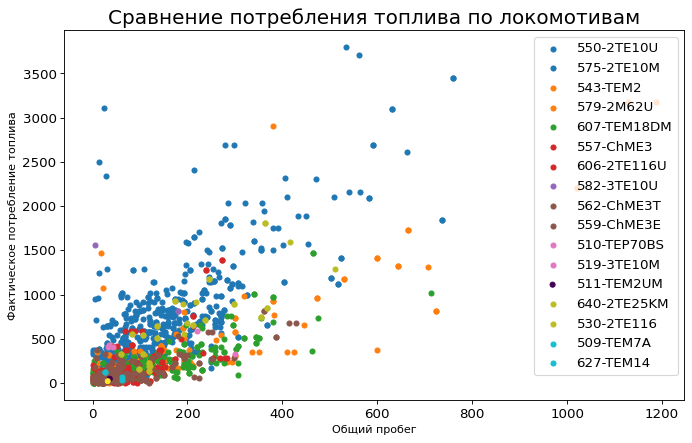

In [ ]:
category = fuel["series"].unique()
colors = [plt.cm.tab10(i/float(len(category)-1)) for i in range(len(category))]

plt.figure(figsize=(10, 6), dpi=80, facecolor="w", edgecolor="k")
for i, cat in enumerate(category):
    plt.scatter('total_mileage', 'fuel_fact',
               data=fuel.loc[fuel.series == cat, :],
                          s = 20, c=colors[i], label=str(cat))

plt.gca().set(xlabel='Общий пробег', ylabel='Фактическое потребление топлива')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Сравнение потребления топлива по локомотивам", fontsize=18)
plt.legend(fontsize=12)
plt.show()

Вывод: наблюдается высокое потребление топлива на километр пробега у локомотивов 550 и 575 серий

## Удалим дубликаты в данных

In [ ]:
# Оценим количество дубликатов
duplicateRows = fuel[fuel.duplicated ()]
duplicateRows.shape

(327, 17)

In [ ]:
# Удалим дубликаты
fuel = fuel.drop_duplicates()
fuel.shape

(1326, 17)

## Дескриптивный анализ (Описательная статистика)

In [ ]:
# Анализ распределения данных
fuel.iloc[:,10:16].describe(include='all')

,total_clock,mileage_linear,total_mileage,gross_work,fuel_normal,fuel_fact
count,1326.000000,1326.00000,1326.000000,1326.000000,1326.000000,1326.000000
mean,10.553243,118.60181,120.716214,49.297760,367.421493,395.688462
std,12.363118,126.66456,128.054695,72.811236,483.572611,493.359085
min,0.200000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,34.00000,34.000000,9.625000,72.675000,78.500000
50%,7.500000,81.00000,81.900000,24.900000,192.000000,227.000000
75%,12.375000,160.00000,167.000000,62.160000,450.725000,532.000000
max,189.700000,1128.00000,1187.700000,877.500000,4489.300000,3799.200000


Описательная статистика исходных данных средствами библиотеки statsmodels - более развернутый вариант, с большим количеством показателей:

In [ ]:
from statsmodels.stats.descriptivestats import Description
result = Description(
    fuel.iloc[:,10:16],
    stats=["mean", "std_err", "ci", "ci", "std", "iqr", "mad", "coef_var", "range", "max", "min", "skew", "kurtosis", "mode",
           "median", "distinct", "top", "freq"],
    use_t=True)
display(result.summary())

mean,10.553242835595777,118.60180995475113,120.7162141779789,49.297760180995475,367.4214932126697,395.6884615384616
std_err,0.33951287923343315,3.4784307108804806,3.5166062609294237,1.9995240879239713,13.27975103154311,13.548504737490196
upper_ci,11.21928425899692,125.42564222617486,127.61493756325706,53.22033853105004,393.4731243008101,422.26732181819403
lower_ci,9.887201412194633,111.7779776833274,113.81749079270074,45.37518183094091,341.3698621245293,369.1096012587291
std,12.363118036696417,126.66455999602154,128.0546952758275,72.81123582715472,483.57261106441445,493.3590845464379
iqr,8.975,126.0,133.0,52.535,378.05,453.5
mad,7.446873642135819,89.1878408168001,90.12267482465779,44.817086464241115,324.77533288289214,339.2073906485671
coef_var,1.1714994366467133,1.0679816778879387,1.0607911799406586,1.4769684375077106,1.3161249954000773,1.2468371774810587
range,189.5,1128.0,1187.7,877.5,4489.3,3799.2
max,189.7,1128.0,1187.7,877.5,4489.3,3799.2
min,0.2,0.0,0.0,0.0,0.0,0.0


### Значение коэффициентов вариации coef_var

Значение показателя coef_var указывает на крайнюю степень рассеяния данных.

- если коэффициент вариации меньше 10%, то степень рассеивания данных считается незначительной
- если от 10% до 20% — средней
- больше 20% и меньше или равно 33% — значительной

Расчет коэффициента осуществляется по формуле:

coef_var = (std/mean)∗100, где
std  — среднеквадратическое отклонение случайной величины;
mean - ожидаемое (среднее) значение случайной величины.

### Симметрия данных  
Сравнение показателей среднего арифметического (mean) и медианы (median) свидетельствует о правосторонней асимметрии (т.к.mean > median). Что говорит о том что маленьких значений существенно больше, чем больших.

### Показатель ассиметрии
Значение показателя асимметрии skew (As) > 2 свидетельствует о положительной асимметрии (Правый перекос).
Распределение считается положительно асимметричным, когда хвостик с правой стороны распределения длиннее хвостика с левой стороны.

При положительно асимметричном распределении среднее значение больше медианы, что больше моды. Это означает, что распределение имеет более длинный хвост по направлению к правой стороне, при этом несколько экстремальных значений смещают среднее значение вправо.

## Визуальная оценка распределения данных

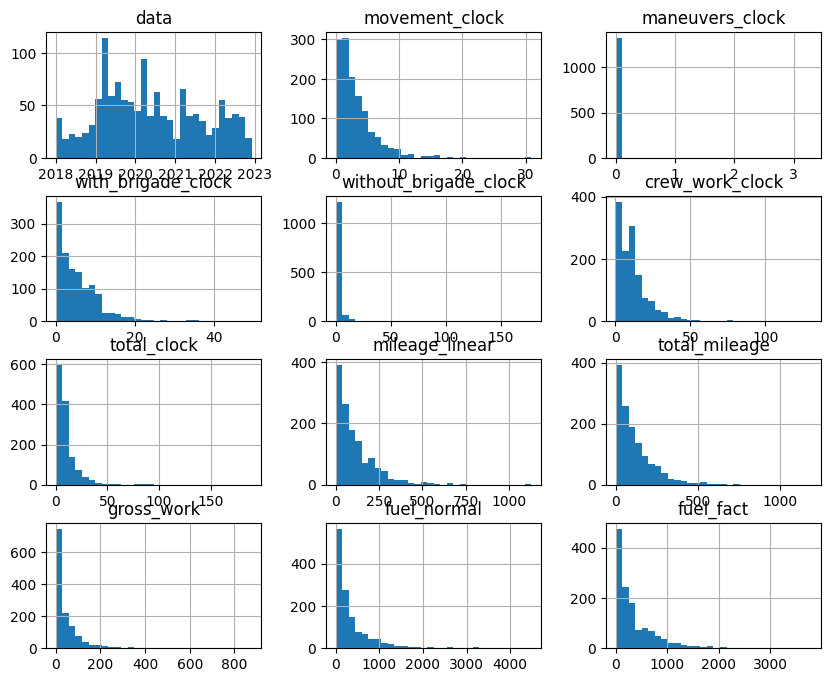

In [ ]:
  fig = plt.figure(figsize = (10,8))
  ax = fig.gca()
  fuel.hist(bins=30, ax = ax);

Наблюдается левостороннее смещение

## Проверка аномальных значений (выбросов)

Проведем эксперимент:
- выполним обучение моделей с удалением значений с нулевым перемещением локомотива total_mileage и с нулевым потреблением топлива fuel_fact. Ожидается, что эти данные не должны улучшать точность предсказания.


- выполним обучение моделей без удаления этих значений.

In [ ]:
# Определим число строк с нулевыми значениями в столбцах total_mileage и fuel_fact
fuel[fuel['total_mileage'] == 0].shape, fuel[fuel['fuel_fact'] == 0].shape

((13, 17), (9, 17))

In [ ]:
# Удалим строки с нулевыми значениями
# fuel = fuel.drop(fuel[fuel['fuel_fact'] == 0].index)
# fuel = fuel.drop(fuel[fuel['total_mileage'] == 0].index)

Вывод по аномальным признакам. В ходе анализа удалось установить, что если оставить данные признаки, то модель предсказывает с большей точностью:
- RMSE с удалением нулевых значений / без удаления нулевых значений:
-- LinearRegression	833.3 / 289.640376
-- RandomForestRegressor 227.96	/ 225.742724
-- DecisionTreeRegressor 308.45	/ 314.780736
-- CatBoostRegressor	177.03 / 177.231602
-- LGBMRegressor	214.5 /  219.336832
-- GradientBoostingRegressor	198.69 / 205.378995

## Корреляционный анализ

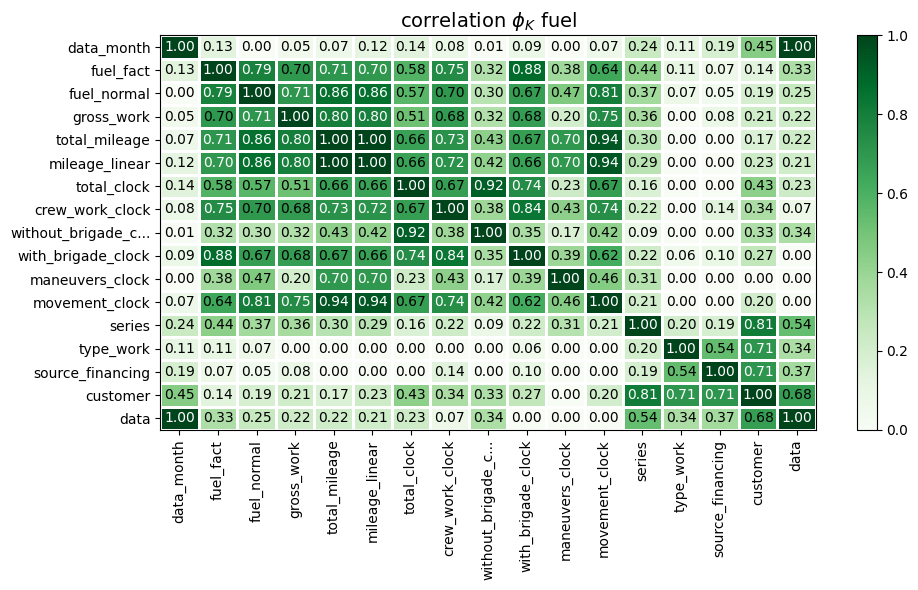

In [ ]:
# корреляционный анализ всех признаков
interval_cols = fuel.select_dtypes(include=["number"]).columns[0:16]
phik_overview = phik_matrix(fuel, interval_cols=interval_cols)
plot_correlation_matrix(phik_overview.values, x_labels=phik_overview.columns, y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens', title=r'correlation $\phi_K$ fuel', fontsize_factor=1.0, figsize=(10, 6))

Вывод:
- Данные столбцов total_mileage и mileage_linear коллинеарны, соответственно в расчётах будем учитывать только один из них.
- Также высокой коллинеарностью обладают признаки mileage_linear и movement_clock (время работы в движении), что логично. На первой итерации удалять не будем.

##  Оценим распределение в данных по категориям

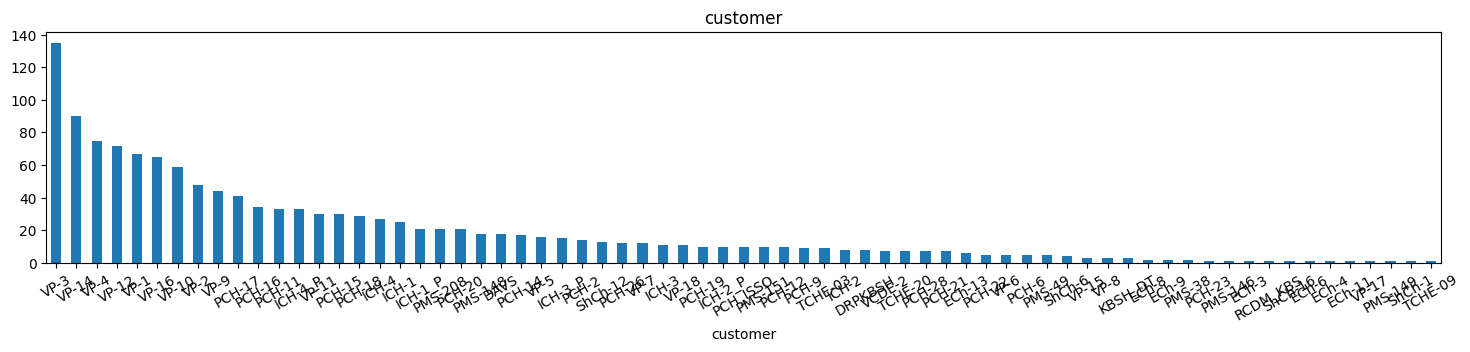

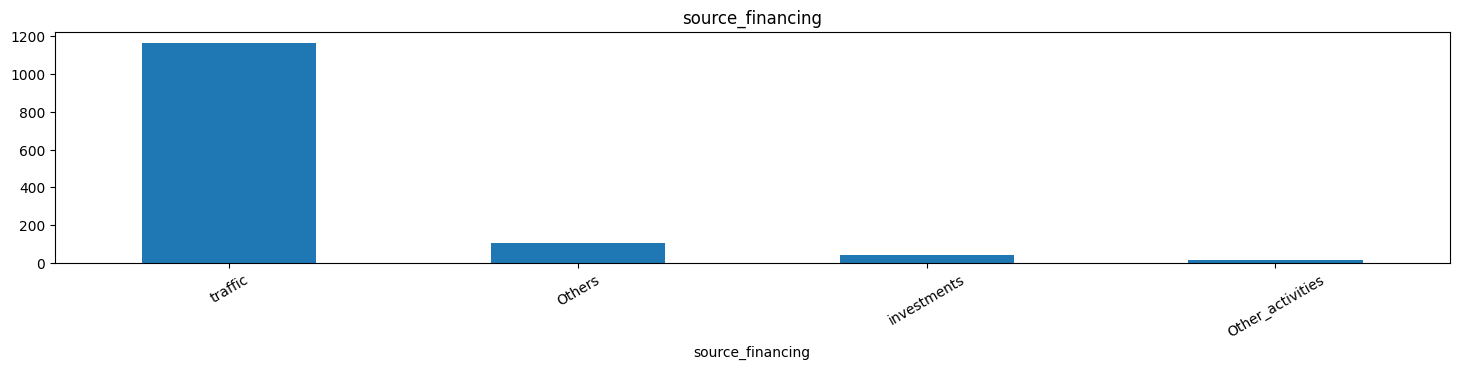

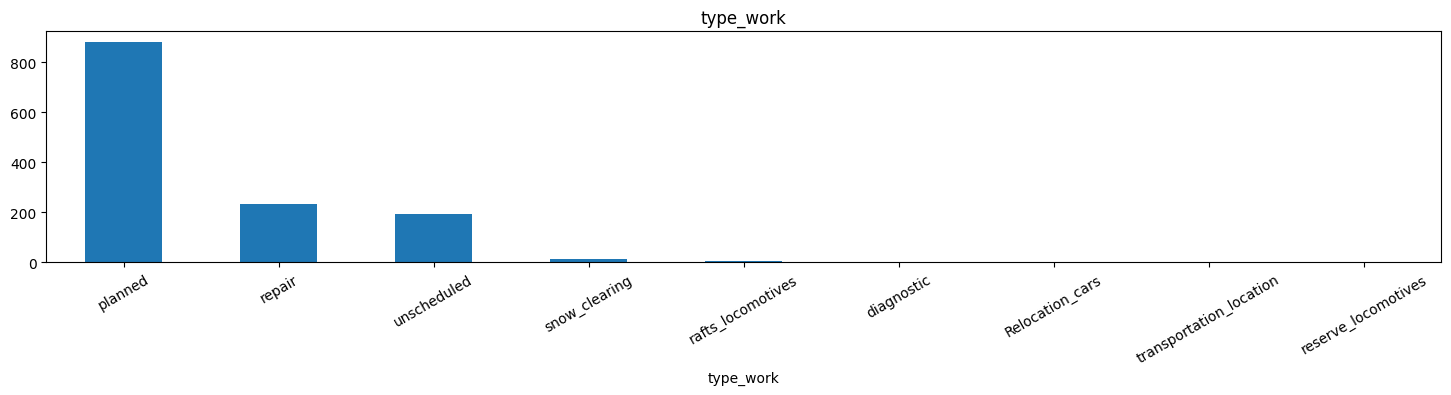

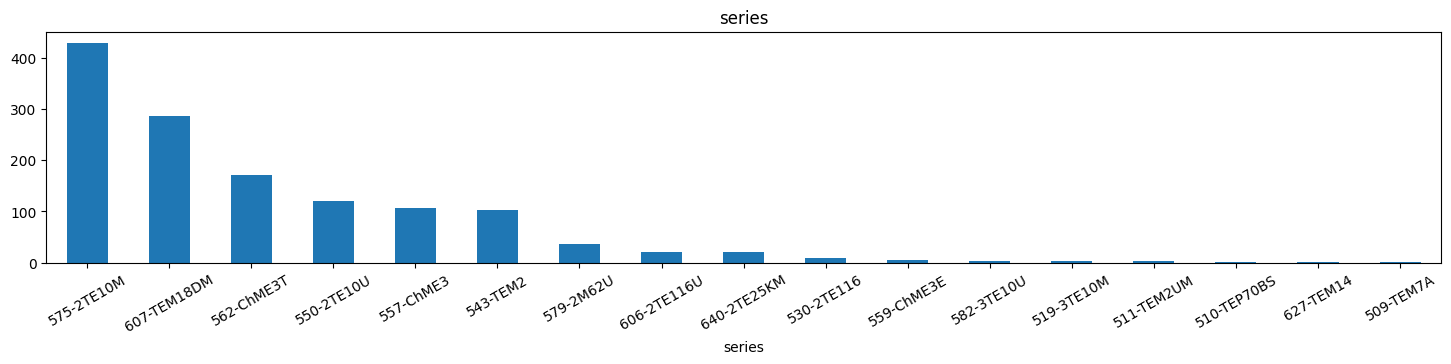

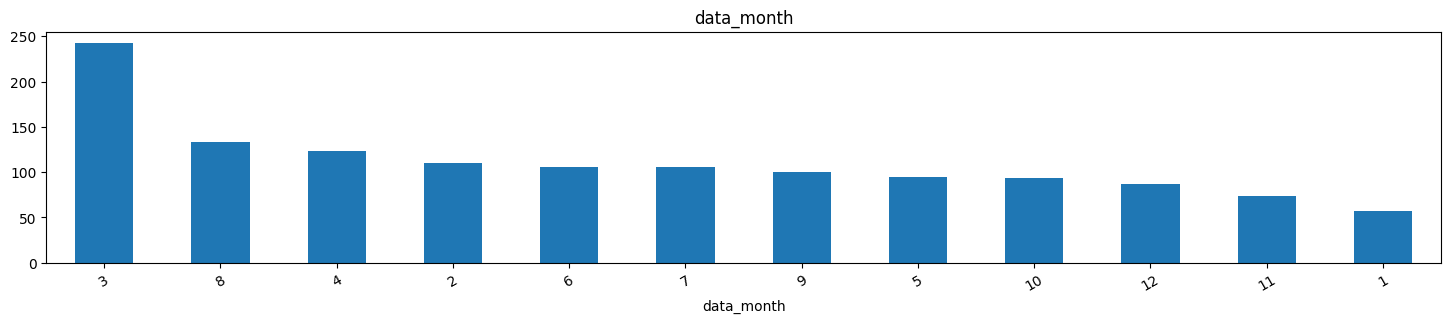

In [ ]:
categorial = fuel.select_dtypes(include=["object"]).columns[0:16] # создаим список категорий
for column in categorial:
    fuel[column].value_counts().plot(kind='bar', title=''+column, figsize=(18,3))
    plt.xticks(rotation=30);
    plt.show()

Категориальный анализ не выявил аномалий

## Оценка связи между типом работы и серией локомотива

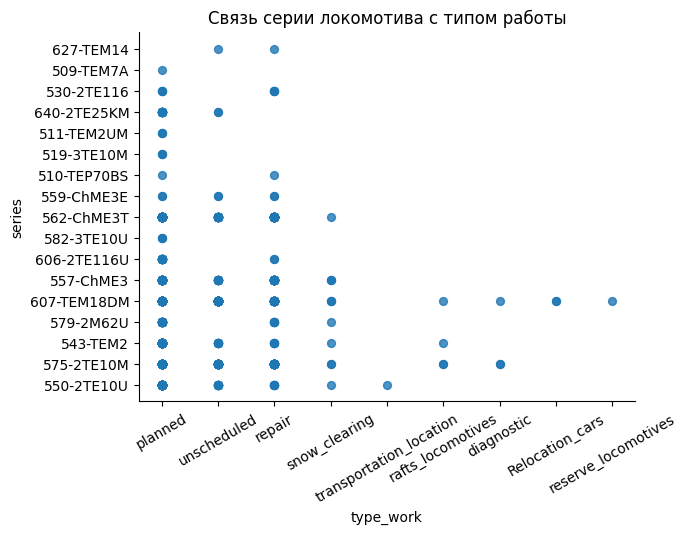

In [ ]:
# Выведем график рассеяния для type_work и series

from matplotlib import pyplot as plt
fuel.plot(kind='scatter', x='type_work', y='series', s=32, alpha=.8)
plt.xticks(rotation=90)
plt.title("Связь серии локомотива с типом работы", fontsize=12)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.xticks(rotation=30);

# Подготовка данных

## Разделим данные на обучающую и тестовую выборки

Выволним деление в отношении 1:4. Удалим в тренировочных данных таргет - 'fuel_fact' и 'fuel_normal', а также 'total_mileage' в связи с коллинеарностью к mileage_linear, в столбце 'maneuvers_clock' - нулевые данные,  а также удалим 'data' вместо неё будет столбец data_month.


In [ ]:
data_target = fuel['fuel_fact'] # таргет
data_features = fuel.drop(['fuel_fact', 'total_mileage', 'fuel_normal', 'maneuvers_clock', 'data'], axis=1) # признаки

# mileage_linear, total_mileage

features_train, features_test, target_train, target_test = train_test_split(
    data_features, data_target, test_size=0.2, random_state = 42)



print(f'Длины обучающей выборки: {len(features_train)}, длина тестовой выборки: {len(features_test)}')

Длины обучающей выборки: 1060, длина тестовой выборки: 266


In [ ]:
# Выделим списки категорий по типам данных

numeric = data_features.select_dtypes(include=["number"]).columns[0:16]
categorial = data_features.select_dtypes(include=["object"]).columns[0:16]
dates = data_features.select_dtypes(include=["datetime64"]).columns[0:16]

In [ ]:
# Оценим тренировочные данные

features_train.head()

,customer,source_financing,type_work,series,movement_clock,with_brigade_clock,without_brigade_clock,crew_work_clock,total_clock,mileage_linear,gross_work,data_month
171,VP-10,traffic,planned,575-2TE10M,2.9,15.0,1.9,28.2,19.8,130.0,87.8,2
271,PCH-18,investments,repair,562-ChME3T,1.6,3.2,0.1,13.0,4.9,62.0,23.9,6
893,VP-1,traffic,planned,543-TEM2,3.2,9.0,3.0,25.7,15.2,128.0,2.3,6
210,PCH-16,traffic,planned,575-2TE10M,2.9,2.7,0.1,14.3,5.7,58.0,49.3,3
722,VP-2,traffic,repair,607-TEM18DM,0.8,0.2,0.0,0.9,1.0,18.0,14.4,8


## Кодирование категориальных данных

Закодируем категориальные данные методом OrdinalEncoder(). Ordinal encoding — это метод, используемый для преобразования категориальных данных в числовые характеристики.

В ordinal encoding каждой уникальной категории присваивается числовое значение на основе её позиции в упорядоченной последовательности. Назначаемые значения сохраняют порядковое отношение между категориями, позволяя модели понимать и использовать присущий порядок во время обучения.

Например, если категориальная переменная представляет цвета (красный, зелёный, синий), то с помощью ordinal encoding эти категории можно сопоставить с числовыми значениями (1, 2, 3).


Для значений, которых не будет в тестовых данных присвоим значение "unknown_value"=1000. Так как при анализе мы выявили, что в данных нет категорий с тысячью различных параметров.

In [ ]:
# Обучим кодировщик на тренировочных данных
ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=1000) # вызов метода
ord.fit(features_train[categorial]) # обучение

OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=1000)

In [ ]:
# Трансформируем данные обученным кодировщиком
features_train[categorial] = ord.transform(features_train[categorial])
features_test[categorial] = ord.transform(features_test[categorial])

In [ ]:
# Оценим работу кодировщика
features_train.head()

,customer,source_financing,type_work,series,movement_clock,with_brigade_clock,without_brigade_clock,crew_work_clock,total_clock,mileage_linear,gross_work,data_month
171,51.0,3.0,2.0,10.0,2.9,15.0,1.9,28.2,19.8,130.0,87.8,1.0
271,23.0,2.0,4.0,9.0,1.6,3.2,0.1,13.0,4.9,62.0,23.9,5.0
893,50.0,3.0,2.0,5.0,3.2,9.0,3.0,25.7,15.2,128.0,2.3,5.0
210,21.0,3.0,2.0,10.0,2.9,2.7,0.1,14.3,5.7,58.0,49.3,2.0
722,58.0,3.0,4.0,14.0,0.8,0.2,0.0,0.9,1.0,18.0,14.4,7.0


## Масштабирование цифровых данных



### Стандартизация
Применим метод StandardScaler - это метод масштабирования на основе среднего. Формула StandardScaler: (Xi-Xmean) / Xstd, поэтому он устанавливает среднее значение как 0.
StandardScaler уязвим для выбросов, поскольку выбросы влияют на среднее значение. Если у вас нормальное распределение или данные, близкие к нормальным, StandardScaler приближает ваши данные к стандартному нормальному распределению.

In [ ]:
numeric

Index(['movement_clock', 'with_brigade_clock', 'without_brigade_clock',
       'crew_work_clock', 'total_clock', 'mileage_linear', 'gross_work'],
      dtype='object')

In [ ]:
# выбор метода масштабирования
scaler = StandardScaler()
# настройка масштабирования на тренировочной выборке
scaler.fit(features_train[numeric])
# масштабирование тренировочной выборки
features_train[numeric] = scaler.transform(features_train[numeric])
# масштабирование тестовой выборки
features_test[numeric] = scaler.transform(features_test[numeric])

In [ ]:
# Оценим работу стандартизатора

features_train.head()

,customer,source_financing,type_work,series,movement_clock,with_brigade_clock,without_brigade_clock,crew_work_clock,total_clock,mileage_linear,gross_work,data_month
171,51.0,3.0,2.0,10.0,-0.128968,1.640306,0.043169,1.279774,0.772547,0.072993,0.482914,1.0
271,23.0,2.0,4.0,9.0,-0.515985,-0.395570,-0.214630,0.074401,-0.456487,-0.445210,-0.355713,5.0
893,50.0,3.0,2.0,5.0,-0.039657,0.605115,0.200713,1.081522,0.393114,0.057751,-0.639193,5.0
210,21.0,3.0,2.0,10.0,-0.128968,-0.481836,-0.214630,0.177492,-0.390499,-0.475692,-0.022362,2.0
722,58.0,3.0,4.0,14.0,-0.754149,-0.913166,-0.228952,-0.885140,-0.778181,-0.780518,-0.480392,7.0


### Нормализация
Помимо стандартизации StandardScaler() есть другой подход к масштабированию — нормализация данных. Она преобразует значения признака в диапазон от нуля до единицы.  Формула нормализации:

·	xi  — значение признака;
·	xmin — минимальное значение признака;
·	xmax — максимальное значение признака.
В sklearn нормализация выполняется с помощью MinMaxScaler(). Вот как его применить:


In [ ]:
# выбор метода масштабирования
# scaler = MinMaxScaler()
# настройка масштабирования на тренировочной выборке
# scaler.fit(features_train[numeric])
# масштабирование тренировочной выборки
# features_train[numeric] = scaler.transform(features_train[numeric])
# масштабирование тестовой выборки
# features_test[numeric] = scaler.transform(features_test[numeric])

### Итог сравнения двух методов масштабирования:

Значимых отличий в метрики точности выявлено не было:
- RMSE стандартизация / нормализация:
-- LinearRegression 295.694233 / 295.694233
-- RandomForestRegressor 236.307259 / 236.225692
-- DecisionTreeRegressor 327.476071 / 327.298019
-- CatBoostRegressor 191.686646 / 191.731011
-- LGBMRegressor 219.908717 / 218.326035
-- GradientBoostingRegressor 204.161590 / 205.005002



# Обучение моделей

Обучим модели на стандартных параметрах для экспресс-оценки их метрики

In [ ]:
# Создадим таблицу для агрегации данных
rmse_result = pd.DataFrame(columns=[],
                      index=["RMSE", "cross_val_time, s"])

In [ ]:
# Создадим свою метрику RMSE
def rmse(predictions, target):
    return abs(mean_squared_error(predictions, target))**0.5
rmse_scorer = make_scorer(rmse, greater_is_better=False)

Для обучения моделей будем использовать Cross-val_score — это функция в Scikit-learn, которая генерирует оценку точности для каждой точки данных в наборе данных.

Она разделяет набор данных на несколько подмножеств — обучающих и тестовых, тренирует модель на каждом подмножестве, делает прогнозы на тестовом подмножестве и выводит оценку точности для каждого подмножества.

Функция cross-val_score оценивает производительность модели на каждой точке данных, помогая лучше понять поведение и слабости модели.

In [ ]:
%%time
# Напишем функцию замера времени поиска лучшей метрики методом кросс валидации
def find_best_default_model(model_dict):
    for model_name in tqdm(model_dict):
        start = time.time()
        model = model_dict[model_name]
        rmse_result.loc["RMSE", model_name] = abs(cross_val_score(model,features_train,target_train, cv=5,scoring=rmse_scorer).mean())
        end = time.time()
        rmse_result.loc["cross_val_time, s", model_name] = end - start

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.82 µs


In [ ]:
# Запустим функцию для следующих моделей
find_best_default_model({'LinearRegression': LinearRegression(),
                         'RandomForestRegressor': RandomForestRegressor(random_state=12345),
                        'DecisionTreeRegressor': DecisionTreeRegressor(random_state=12345),
                         'CatBoostRegressor': CatBoostRegressor(verbose=False),
                        'LGBMRegressor': LGBMRegressor(),
                         'GradientBoostingRegressor': GradientBoostingRegressor()})

 67%|██████▋   | 4/6 [00:20<00:13,  6.84s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1089
[LightGBM] [Info] Number of data points in the train set: 848, number of used features: 12
[LightGBM] [Info] Start training from score 396.523585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1084
[LightGBM] [Info] Number of data points in the train set: 848, number of used features: 12
[LightGBM] [Info] Start training from score 411.288915
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

 83%|████████▎ | 5/6 [00:20<00:04,  4.52s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1095
[LightGBM] [Info] Number of data points in the train set: 848, number of used features: 12
[LightGBM] [Info] Start training from score 396.701179
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1100
[LightGBM] [Info] Number of data points in the train set: 848, number of used features: 12
[LightGBM] [Info] Start training from score 392.095755
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


100%|██████████| 6/6 [00:22<00:00,  3.67s/it]


In [ ]:
rmse_result

,LinearRegression,RandomForestRegressor,DecisionTreeRegressor,CatBoostRegressor,LGBMRegressor,GradientBoostingRegressor
RMSE,295.694233,236.307259,327.476071,191.686646,219.908717,205.545938
"cross_val_time, s",0.118866,6.091451,0.244819,14.095607,0.399676,1.059679


### Вывод
После обучения моделей на стандартных параметрах установлено:
* лидер по скорости - линейная регрессия (по качеству хуже всех)
* лидер по качеству предсказания - CatBoostRegressor

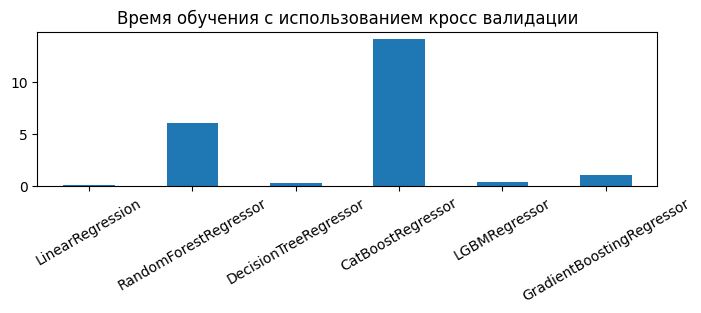

In [ ]:
# Визуализация скорости обучения на кроссвалидации
rmse_result.iloc[1].plot(kind='bar', title='Время обучения с использованием кросс валидации', figsize=(8,2))
plt.xticks(rotation=30);

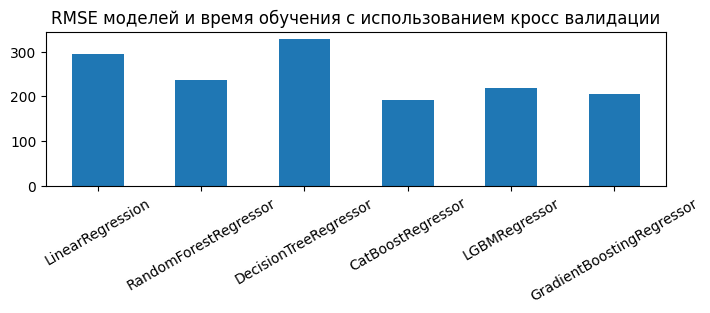

In [ ]:
# Визуализация метрики RMSE обучения на кроссвалидации

rmse_result.iloc[0].plot(kind='bar', title='RMSE моделей и время обучения с использованием кросс валидации', figsize=(8,2))
plt.xticks(rotation=30);

## Анализ моделей

Выполним поиск лучших гиперпараметров моделей с помощью метода GridSearchCV().

GridSearchCV — это функция в scikit-learn, которая автоматизирует процесс настройки гиперпараметров и помогает найти лучшие параметры для заданной модели машинного обучения.

GridSearchCV работает следующим образом:

- Определяет сетку гиперпараметров.

- Систематически тренирует и оценивает модель машинного обучения для каждой комбинации гиперпараметров.

- Выбирает лучший набор параметров на основе указанной метрики производительности.

Для использования GridSearchCV необходимо указать:

- Гиперпараметры, которые нужно настроить.

- Модель машинного обучения.

- Метрику производительности, которая будет использоваться для оценки различных комбинаций гиперпараметров.

In [ ]:
# Создадим таблицу для агрегации данных

result = pd.DataFrame(index=[],
                      columns=["RMSE", "learning_time", "predict_time"])

### Функция для вычисления точности модели при разных гиперпараметрах

In [ ]:
# Напишем функцию для вычисления точности модели с помощью алгоритма GridSearchCV и пользовательской метрики

def best_hypers_for_model(model, hyperparams, scorer):

    clf = GridSearchCV(model, hyperparams, scoring=scorer)
    clf.fit(features_train, target_train)
    print(str(model)[:-2],"Best parameters set found on development set:\n")
    print(clf.best_params_)
    print("\nGrid scores on development set:\n")
    for mean, std, params in zip(clf.cv_results_['mean_test_score'], clf.cv_results_['std_test_score'], clf.cv_results_['params']):
        print("%0.6f for %r"% (abs(mean), params))

### Функция расчёта времени обучения и времени предсказания моделей

In [ ]:
# Напишем функцию расчёта времени обучения и времени предсказания моделей

def best_model_result(model_dict):

    for model_name in tqdm(model_dict):
        l_start = time.time()
        model = model_dict[model_name]
        model.fit(features_train, target_train)
        l_end = time.time()
        result.loc[model_name, "learning_time"] = l_end - l_start
        p_start = time.time()
        predictions = model.predict(features_test)
        p_end = time.time()
        result.loc[model_name, "predict_time"] = p_end - p_start
        result.loc[model_name, "RMSE"] = rmse(predictions, target_test)

## Оценим модели на интервалах гиперпараметров

### DecisionTreeRegressor
Decision Tree Regression — строит структуру в виде дерева, разделяя данные на основе значений различных признаков. Для прогнозирования новых образцов данных используется среднее значение целевой переменной из листового узла.

Алгоритм обрабатывает как категориальные, так и непрерывные переменные, что делает его универсальным для задач регрессии.

In [ ]:
# Зададим диапазон гиперпараметров

MODEL_SETTINGS = { 'max_depth': list(range(1, 10)),
                   'min_samples_split': list(np.arange(0.001, 0.002, 0.001)), # cгенерируем последовательность от 0.001 до 0.02 с шагом 0.01,
                                # минимальное количество выборок для каждого разделения при этом будет: .ceil(min_samples_split * n_samples)
                   'random_state': [12345] }

best_hypers_for_model(DecisionTreeRegressor(), MODEL_SETTINGS, rmse_scorer)

DecisionTreeRegressor Best parameters set found on development set:

{'max_depth': 7, 'min_samples_split': 0.001, 'random_state': 12345}

Grid scores on development set:

424.793472 for {'max_depth': 1, 'min_samples_split': 0.001, 'random_state': 12345}
368.842980 for {'max_depth': 2, 'min_samples_split': 0.001, 'random_state': 12345}
336.250159 for {'max_depth': 3, 'min_samples_split': 0.001, 'random_state': 12345}
329.461497 for {'max_depth': 4, 'min_samples_split': 0.001, 'random_state': 12345}
325.169802 for {'max_depth': 5, 'min_samples_split': 0.001, 'random_state': 12345}
322.139568 for {'max_depth': 6, 'min_samples_split': 0.001, 'random_state': 12345}
313.935790 for {'max_depth': 7, 'min_samples_split': 0.001, 'random_state': 12345}
316.863151 for {'max_depth': 8, 'min_samples_split': 0.001, 'random_state': 12345}
319.477480 for {'max_depth': 9, 'min_samples_split': 0.001, 'random_state': 12345}


### RandomForestRegressor

Random Forest — это универсальный алгоритм машинного обучения, который использует ансамбль решающих деревьев.

Он применяется для решения практически любых проблем в области машинного обучения, включая задачи классификации и регрессии, а также более сложные задачи, такие как отбор признаков, поиск выбросов и аномалий, кластеризация.

Преимущества алгоритма:

- высокая точность предсказания;
- не требует тщательной настройки параметров;
- практически не чувствителен к выбросам в данных;
- нечувствителен к масштабированию и другим монотонным преобразованиям значений признаков;
- редко переобучается;
- эффективно обрабатывает данные с большим числом признаков и классов;
- хорошо работает с пропущенными данными.

Недостатки алгоритма:

- для реализации требуется значительный объём вычислительных ресурсов;
- большой размер моделей;
- построение случайного леса отнимает больше времени, чем деревья решений или линейные алгоритмы;
- алгоритм склонен к переобучению на зашумлённых данных.

In [ ]:
# Зададим диапазон гиперпараметров

MODEL_SETTINGS = { 'n_estimators': list(range(25, 30, 1)),
                   'max_depth': list(range(12, 16)),
                   'random_state': [12345] }

best_hypers_for_model(RandomForestRegressor(), MODEL_SETTINGS, rmse_scorer)

RandomForestRegressor Best parameters set found on development set:

{'max_depth': 14, 'n_estimators': 28, 'random_state': 12345}

Grid scores on development set:

240.701151 for {'max_depth': 12, 'n_estimators': 25, 'random_state': 12345}
240.527682 for {'max_depth': 12, 'n_estimators': 26, 'random_state': 12345}
240.033557 for {'max_depth': 12, 'n_estimators': 27, 'random_state': 12345}
239.196577 for {'max_depth': 12, 'n_estimators': 28, 'random_state': 12345}
239.872094 for {'max_depth': 12, 'n_estimators': 29, 'random_state': 12345}
239.941450 for {'max_depth': 13, 'n_estimators': 25, 'random_state': 12345}
239.841797 for {'max_depth': 13, 'n_estimators': 26, 'random_state': 12345}
239.364919 for {'max_depth': 13, 'n_estimators': 27, 'random_state': 12345}
238.596458 for {'max_depth': 13, 'n_estimators': 28, 'random_state': 12345}
239.000768 for {'max_depth': 13, 'n_estimators': 29, 'random_state': 12345}
236.823757 for {'max_depth': 14, 'n_estimators': 25, 'random_state': 12345}


### CatBoostRegressor

CatBoostRegressor — это модель машинного обучения для задач регрессии, которая является частью библиотеки CatBoost.

Она реализует градиентное усиление на деревьях решений и специально предназначена для работы с категориальными данными и отсутствующими значениями.

Для обучения модели CatBoostRegressor требуется обучающий набор данных, включающий как характеристики, так и целевую переменную для прогнозирования. Модель учится делать прогнозы для цели, подгоняя серию деревьев решений к обучающим данным.

CatBoostRegressor известен своей высокой производительностью и способностью обрабатывать большие и сложные наборы данных.

In [ ]:
# Зададим диапазон гиперпараметров

MODEL_SETTINGS = {'verbose':[False],
                  'n_estimators': list(range(347, 353, 1)),
                  'max_depth': list(range(4, 8, 1)),
                  'random_state': [12345]  }

best_hypers_for_model(CatBoostRegressor(), MODEL_SETTINGS, rmse_scorer)

<catboost.core.CatBoostRegressor object at 0x7b72e2f9343 Best parameters set found on development set:

{'max_depth': 6, 'n_estimators': 349, 'random_state': 12345, 'verbose': False}

Grid scores on development set:

192.315849 for {'max_depth': 4, 'n_estimators': 347, 'random_state': 12345, 'verbose': False}
189.261325 for {'max_depth': 4, 'n_estimators': 348, 'random_state': 12345, 'verbose': False}
192.397907 for {'max_depth': 4, 'n_estimators': 349, 'random_state': 12345, 'verbose': False}
189.835401 for {'max_depth': 4, 'n_estimators': 350, 'random_state': 12345, 'verbose': False}
190.734615 for {'max_depth': 4, 'n_estimators': 351, 'random_state': 12345, 'verbose': False}
192.173316 for {'max_depth': 4, 'n_estimators': 352, 'random_state': 12345, 'verbose': False}
187.895046 for {'max_depth': 5, 'n_estimators': 347, 'random_state': 12345, 'verbose': False}
188.980020 for {'max_depth': 5, 'n_estimators': 348, 'random_state': 12345, 'verbose': False}
188.802094 for {'max_depth': 5,

### GradientBoostingRegressor

Градиентный бустинг (Gradient Boosting) — это продвинутый алгоритм машинного обучения для решения задач классификации и регрессии.

Он строит предсказание в виде ансамбля слабых предсказывающих моделей, которыми в основном являются деревья решений. Из нескольких слабых моделей в итоге собирают одну, но уже эффективную.

Общая идея алгоритма — последовательное применение предиктора (предсказателя) таким образом, что каждая последующая модель сводит ошибку предыдущей к минимуму.

Для алгоритма градиентного бустинга существуют три наиболее используемые библиотеки:

- XGBoost,
- CatBoost.

Преимущества:

- Алгоритм работает с любыми функциями потерь.
- Предсказания в среднем лучше, чем у других алгоритмов.
- Самостоятельно справляется с пропущенными данными.

Недостатки:

- Алгоритм крайне чувствителен к выбросам и при их наличии будет тратить огромное количество ресурсов.
- Модель будет склонна к переобучению при слишком большом количестве деревьев.
- Вычисления могут занять много времени.

In [ ]:
# Зададим диапазон гиперпараметров

MODEL_SETTINGS = {  'n_estimators': list(range(95, 105, 1)),
                    'max_depth': list(range(2, 5, 1)),
                    'random_state': [12345]  }

best_hypers_for_model(GradientBoostingRegressor(), MODEL_SETTINGS, rmse_scorer)

GradientBoostingRegressor Best parameters set found on development set:

{'max_depth': 3, 'n_estimators': 103, 'random_state': 12345}

Grid scores on development set:

223.105274 for {'max_depth': 2, 'n_estimators': 95, 'random_state': 12345}
222.878982 for {'max_depth': 2, 'n_estimators': 96, 'random_state': 12345}
222.726727 for {'max_depth': 2, 'n_estimators': 97, 'random_state': 12345}
222.490317 for {'max_depth': 2, 'n_estimators': 98, 'random_state': 12345}
222.062926 for {'max_depth': 2, 'n_estimators': 99, 'random_state': 12345}
221.830540 for {'max_depth': 2, 'n_estimators': 100, 'random_state': 12345}
221.483831 for {'max_depth': 2, 'n_estimators': 101, 'random_state': 12345}
221.320433 for {'max_depth': 2, 'n_estimators': 102, 'random_state': 12345}
221.231904 for {'max_depth': 2, 'n_estimators': 103, 'random_state': 12345}
221.235559 for {'max_depth': 2, 'n_estimators': 104, 'random_state': 12345}
205.772824 for {'max_depth': 3, 'n_estimators': 95, 'random_state': 12345}
20

### LGBMRegressor

LightGBM (Light Gradient Boosting Machine) — это высокопроизводительный фреймворк с открытым исходным кодом для повышения градиента, разработанный для эффективных и масштабируемых задач машинного обучения.

Ключевые характеристики LightGBM:

- способность обрабатывать большие наборы данных с миллионами строк и столбцов;
- поддержка параллельных и распределённых вычислений;
- оптимизированные алгоритмы повышения градиента.
- LightGBM известен своей превосходной скоростью и низким потреблением памяти благодаря методам, основанным на гистограммах, и росту деревьев по листьям.

In [ ]:
# Зададим диапазон гиперпараметров

MODEL_SETTINGS = {
    'n_estimators': list(range(150, 152, 1)),
    'max_depth': list(range(10, 13, 1)),
    'random_state': [12345]
                  }
best_hypers_for_model(LGBMRegressor(),MODEL_SETTINGS,rmse_scorer)

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1089
[LightGBM] [Info] Number of data points in the train set: 848, number of used features: 12
[LightGBM] [Info] Start training from score 396.523585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

### Обучение лучших моделей

Обучим модели с лучшими гиперпараметрами с замером времени обучения и временем предсказания

In [ ]:
best_model_result({ 'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=7, min_samples_split=0.001, random_state=12345),
                   'RandomForestRegressor': RandomForestRegressor(max_depth=14, n_estimators=28, random_state=12345),
                   'CatBoostRegressor': CatBoostRegressor(max_depth=6, n_estimators=349, random_state=12345, verbose=False),
                    'GradientBoostingRegressor': GradientBoostingRegressor(max_depth=3, n_estimators=103, random_state=12345),
                  'LGBMRegressor': LGBMRegressor(max_depth=11, n_estimators=150, random_state=12345)})

100%|██████████| 5/5 [00:01<00:00,  3.99it/s]

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1248
[LightGBM] [Info] Number of data points in the train set: 1060, number of used features: 12
[LightGBM] [Info] Start training from score 397.814623
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [ ]:
result

,RMSE,learning_time,predict_time
DecisionTreeRegressor,263.925949,0.010116,0.001634
RandomForestRegressor,192.48876,0.189761,0.003942
CatBoostRegressor,139.943636,0.63359,0.001625
GradientBoostingRegressor,175.76453,0.259283,0.00218
LGBMRegressor,179.455768,0.133664,0.004657


### Вывод по обучению на лучших признаках
* Высокая скорость обучения у DecisionTreeRegressor

* Высокая скорость предсказания: DecisionTreeRegressor
       
* Лучший параметр качества предсказания: CatBoostRegressor

In [ ]:
result.index


Index(['DecisionTreeRegressor', 'RandomForestRegressor', 'CatBoostRegressor',
       'GradientBoostingRegressor', 'LGBMRegressor'],
      dtype='object')

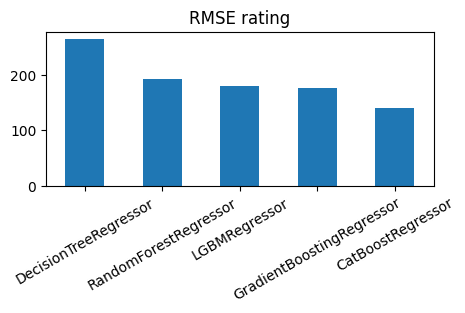

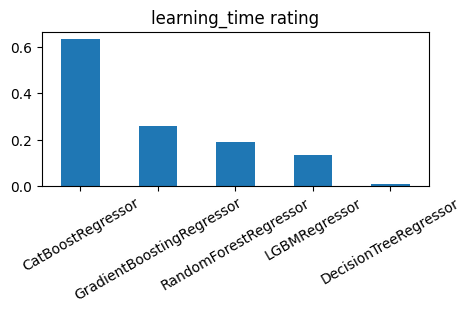

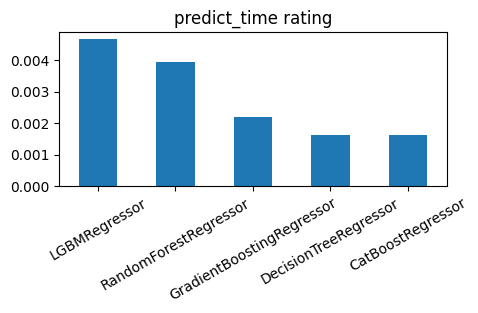

In [ ]:
# Визуализируем сравнение скорости обучения, точности предсказания и времени предсказания моделей с лучшими гиперпараметрами

for column in result.columns:
    result[column].sort_values(ascending=False).plot(kind='bar', title=column+" rating", figsize=(5, 2))
    plt.xticks(rotation=30)
    plt.show();

## Оценка важности признаков лучшей модели

In [ ]:
# Выведем значения из под функции для оценки важности признаков

print('CatBoostRegressor - loss_function="RMSE", max_depth=6, n_estimators=349, random_state=12345, verbose=False')
best_cat = CatBoostRegressor(loss_function="RMSE", max_depth = 6, n_estimators = 349, random_state=12345, verbose=False)
best_cat.fit(features_train, target_train, plot=True)
best_cat_predictions_test = best_cat.predict(features_test)
best_cat_rmse_test = mean_squared_error(target_test, best_cat_predictions_test, squared=False)
print('RMSE на тестовой выборке:', best_cat_rmse_test)

CatBoostRegressor - loss_function="RMSE", max_depth=6, n_estimators=349, random_state=12345, verbose=False


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

RMSE на тестовой выборке: 139.943635983812


In [ ]:
# Создадим список анализируемых моделей

result = [best_cat]

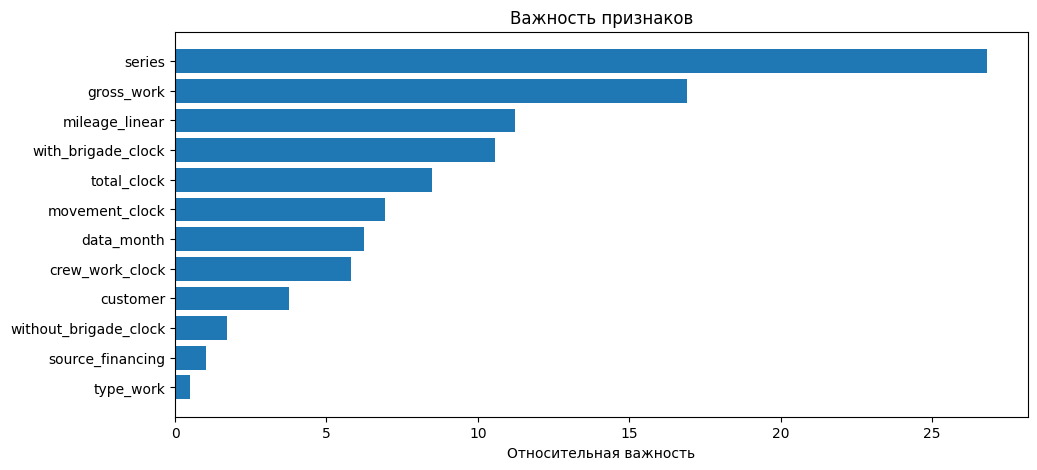

In [ ]:
# Напишем функцию визуализирующую важность признаков графически

def disaplay_features_importances(model, features):
    features = features.columns
    n = len(features)

    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(11, 5))
    plt.title('Важность признаков')
    plt.barh(range(n), importances[indices])
    plt.yticks(range(len(indices)), features[indices])
    plt.xlabel('Относительная важность')
    plt.show()

for model_results in result:
    print(model_results)
    disaplay_features_importances(model_results, features_test);

### Лидирующие признаки
- Серия - series
- Работа брутто, 10^3 ткм: gross_work
- Пробег линейный, км: mileage_linear
- Простои с бригадой: with_brigade_clock
- Всего: total_clock
- Работа в движении, локомотиво-часы: movement_clock
- Месяц движения: data_month

## Анализ точности методов

### RMSE для методов апроксимации
Вычислим RMSE для данных вычисленных методом апроксимации в соответствии методикой планирования показателей работы локомотивов и моторвагонного подвижного состава в хозяйственном движении для целей нормирования топливно-энергетических ресурсов на тягу поездов.

In [ ]:
fuel_rmse = fuel[['series', 'gross_work', 'mileage_linear', 'with_brigade_clock', 'total_clock', 'data', 'fuel_normal', 'fuel_fact']]
fuel_rmse.head()

,series,gross_work,mileage_linear,with_brigade_clock,total_clock,data,fuel_normal,fuel_fact
0,550-2TE10U,72.5,0.0,1.2,3.2,2018-01-01,367.8,367.8
1,575-2TE10M,16.7,0.0,2.9,3.4,2018-01-01,50.1,103.1
2,543-TEM2,29.0,0.0,8.0,10.1,2018-01-01,249.3,113.0
3,579-2M62U,179.4,0.0,20.8,30.4,2018-01-01,1077.9,1077.9
4,543-TEM2,14.0,0.0,3.4,6.6,2018-01-01,92.5,132.4


In [ ]:
RMSE_rgd = ((fuel_rmse['fuel_normal'] - fuel_rmse['fuel_fact']) ** 2).mean() ** .5
RMSE_rgd

262.43791873803895

### Анализ остатков
Основное правило анализа остатков: если модель правильно подобрана к исходным данным, то в остатках не должно остаться никаких закономерностей. Систематические паттерны в остатках означают, что модель не учитывает какие-то входные признаки, которые влияют на целевой.


In [ ]:
# Добавим в таблицу с тестовыми данными предсказания модели

features_test['fuel_predict'] = best_cat_predictions_test.tolist()
features_test = features_test.sort_index()
fuel_predict = features_test['fuel_predict'].sort_index()
fuel_filtered = fuel[fuel.index.isin (features_test.index)]
fuel_filtered['fuel_predict'] = fuel_predict
fuel_filtered.head()

,data,customer,source_financing,type_work,series,movement_clock,maneuvers_clock,with_brigade_clock,without_brigade_clock,crew_work_clock,total_clock,mileage_linear,total_mileage,gross_work,fuel_normal,fuel_fact,data_month,fuel_predict
24,2018-03-01,VP-16,traffic,planned,579-2M62U,3.1,0.0,6.0,1.8,9.5,10.9,0.0,7.8,16.3,116.9,164.0,3,233.295791
30,2018-03-01,VP-9,traffic,planned,575-2TE10M,6.0,0.0,4.4,0.3,16.6,10.7,0.0,4.7,235.3,673.2,946.8,3,955.280611
32,2018-03-01,PCH-15,traffic,planned,575-2TE10M,4.1,0.0,11.0,2.0,16.1,17.1,0.0,13.0,204.5,1012.6,1240.6,3,1096.508174
33,2018-03-01,PCH-20,traffic,repair,579-2M62U,3.1,0.0,4.6,0.0,15.1,7.7,0.0,4.6,9.2,74.1,123.7,3,156.979791
44,2018-04-01,VP-3,traffic,planned,575-2TE10M,16.2,0.0,14.4,0.2,46.9,30.8,0.0,14.6,248.2,2575.9,2498.4,4,2023.707101


### График рассеяния остатков

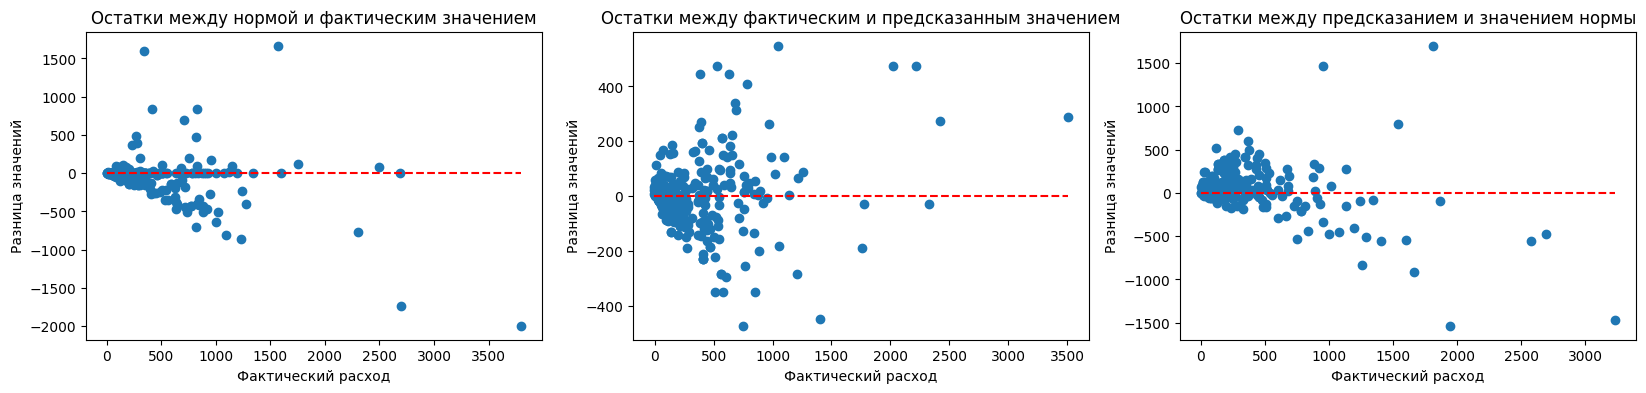

In [ ]:
# Проанализируем остатки с помощью графиков.
# Для анализа остатков построим график, отображающий разницу между предсказанными фатическими значениями целевой переменной
# и предсказанными значениями. Также добавим линию с нулевыми остатками.

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

residuals1 = fuel_filtered['fuel_normal'] - fuel_filtered['fuel_fact']
axes[0].scatter(fuel_filtered['fuel_fact'], residuals1)
axes[0].plot([min(fuel_filtered['fuel_fact']), max(fuel_filtered['fuel_fact'])], [0, 0], color='red', linestyle='--')
axes[0].set_xlabel('Фактический расход')
axes[0].set_ylabel("Разница значений")
axes[0].set_title("Остатки между нормой и фактическим значением");

residuals2 = fuel_filtered['fuel_fact'] - fuel_filtered['fuel_predict']
axes[1].scatter(fuel_filtered['fuel_predict'], residuals2)
axes[1].plot([min(fuel_filtered['fuel_predict']), max(fuel_filtered['fuel_predict'])], [0, 0], color='red', linestyle='--')
axes[1].set_xlabel('Фактический расход')
axes[1].set_ylabel("Разница значений")
axes[1].set_title("Остатки между фактическим и предсказанным значением");

residuals3 = fuel_filtered['fuel_predict'] - fuel_filtered['fuel_normal']
axes[2].scatter(fuel_filtered['fuel_normal'], residuals3)
axes[2].plot([min(fuel_filtered['fuel_normal']), max(fuel_filtered['fuel_normal'])], [0, 0], color='red', linestyle='--')
axes[2].set_xlabel('Фактический расход')
axes[2].set_ylabel("Разница значений")
axes[2].set_title("Остатки между предсказанием и значением нормы");

-	Случайность остатков модели: остатки должны быть нормально распределены, а их график — симметричен относительно самого частого значения;
-	Устойчивость остатков модели: остатки должны иметь постоянную дисперсию на всём интервале использования модели.
Если два эти условия соблюдены, то модель справляется с задачей. Рассмотрим подробно каждое из них.

### Распредение остатков относительно нуля

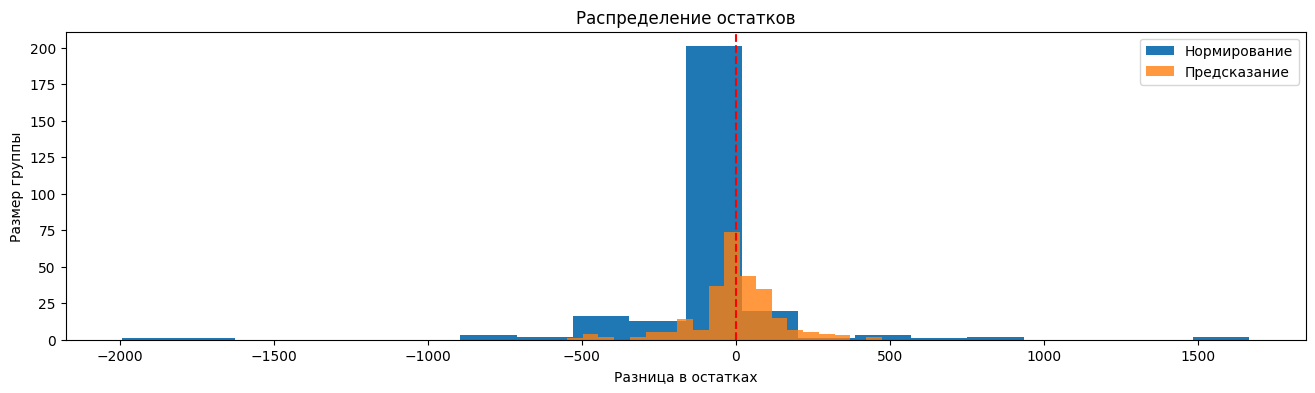

In [ ]:
fig, axes = plt.subplots(1, figsize=(16, 4))

plt.hist(fuel_filtered['fuel_normal'] - fuel_filtered['fuel_fact'], bins=20, alpha = 1, label='Нормирование')
plt.hist(fuel_filtered['fuel_predict'] - fuel_filtered['fuel_fact'], bins=20, alpha = 0.8, label='Предсказание')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Разница в остатках')
plt.ylabel("Размер группы")
plt.legend()
plt.title("Распределение остатков");

### Коэффициенты детерминации

Расчёт и свойства R²  — коэффициент детерминации, известный как R².

R² = 1- MSE/D

Модель работает точно, если ошибка равна нулю:  R² =1−0=1. Если же ошибка в числителе дроби будет намного больше дисперсии, сама дробь будет значительно больше единицы, а коэффициент детерминации примет отрицательное значение. Такая модель настолько неэффективна, что среднее значение оказывается ближе к истинному, чем предсказанное.
Коэффициент детерминации оценивает обобщающую способность модели. Это значит, что он определяет, насколько хорошо модель «объясняет», предсказывает целевой признак по входным.


In [ ]:
r2_1 = r2_score(fuel_filtered['fuel_normal'], fuel_filtered['fuel_predict'])
print('R2 между нормой и предсказанием:', r2_1.round(3))
r2_2 = r2_score(fuel_filtered['fuel_normal'], fuel_filtered['fuel_fact'])
print('R2 между нормой и фактом:', r2_2.round(3))
r2_3 = r2_score(fuel_filtered['fuel_fact'], fuel_filtered['fuel_predict'])
print('R2 между фактом и предсказанием:', r2_3.round(3))

R2 между нормой и предсказанием: 0.603
R2 между нормой и фактом: 0.588
R2 между фактом и предсказанием: 0.915


Вывод: модель выполняет предсказания точнее, чем нормирование.

## Проверка адекватности модели

Очень важно также проверить лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки?

В качестве константной модели можно использовать DummyRegressor (https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) - эта модель как раз создана для генерирования константных предсказаний.

Важно, чтобы результат тестирования нашей модели на тествой выборке был лучше, чем результат константной модели - в противном случае наша модель является бесполезной, так как все наши усилия над проектом не принесли результата, а можель, просто предсказывющая среднее на train, делает нашу работу лучше.

In [ ]:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(features_train, target_train)

# Predict target values for new data
y_pred = dummy_regr.predict(features_test)

rmse_dummy_regr = mean_squared_error(best_cat_predictions_test, y_pred, squared=False)
rmse_dummy_regr

435.32380159341386

Точность предсказания на средних значения значительно хуже, а значит модель адекватна.

## Диграмма размаха для значений потребления топлива разных серий локомотива

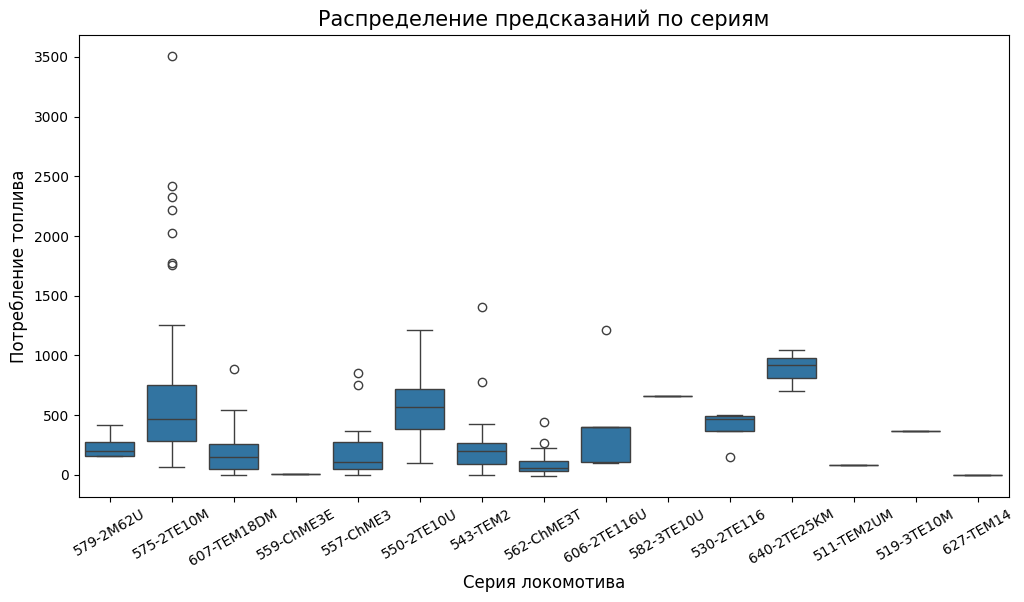

In [ ]:
#Отрисуем ящики с усами для предсказаний потребления топлива по сериям локомотивов.
plt.figure(figsize=(12,6))
sns.boxplot(data = fuel_filtered, x ='series', y='fuel_predict')
plt.title('Распределение предсказаний по сериям', fontsize=15)
plt.xlabel('Серия локомотива', fontsize=12)
plt.xticks(rotation=30)
plt.ylabel('Потребление топлива',fontsize=12);

In [ ]:
uploaded = files.upload()

In [ ]:
Image('ZN8N6.png')

FileNotFoundError: No such file or directory: 'ZN8N6.png'

FileNotFoundError: No such file or directory: 'ZN8N6.png'

<IPython.core.display.Image object>

## Тест Уайта на гетероскедастичность

## Оценка объемов потребления
Определим объёмы топлива, которые предсказывает модель, определяет нормирование и сравним эти объемы с фактическим значением.
Построим график потребления по месяцам.

In [ ]:
# Сгруппируем потребление топлива по месяцам

fuel_value = fuel_filtered[['data', 'fuel_normal', 'fuel_fact', 'fuel_predict'	]]
fuel_value_group = fuel_value.groupby(by=['data']).sum()
fuel_value_group.head(5)

,fuel_normal,fuel_fact,fuel_predict
data,,,
2018-03-01,1876.8,2475.1,2442.064367
2018-04-01,4285.6,3516.7,3093.267525
2018-05-01,1763.7,1883.5,1859.697043
2018-06-01,1115.5,2039.3,1796.518627
2018-07-01,3232.6,1567.0,1757.470158


In [ ]:
# Посчитаем объём топлива, который определяет нормирование, факт и предсказание

print(f"{fuel_value['fuel_normal'].sum()} объём топлива, который определяет нормирование")

print(f"{fuel_value['fuel_fact'].sum()} фактический объём топлива")

print(f"{fuel_value['fuel_predict'].sum().round(2)} предсказанный объём топлива")

90665.6 объём топлива, который определяет нормирование
102999.4 фактический объём топлива
103102.78 предсказанный объём топлива


Потребление согласно предсказанным значениям подразумевает более точное планирование объемов топлива, чем при нормировании апроксимацией, которое занижает значения, что также видно на графике рассеяния остатков.

### Сравнительный анализ месячных объемов

Построим график потребления топлива согласно нормированию, предсказанию и факту помесячно.

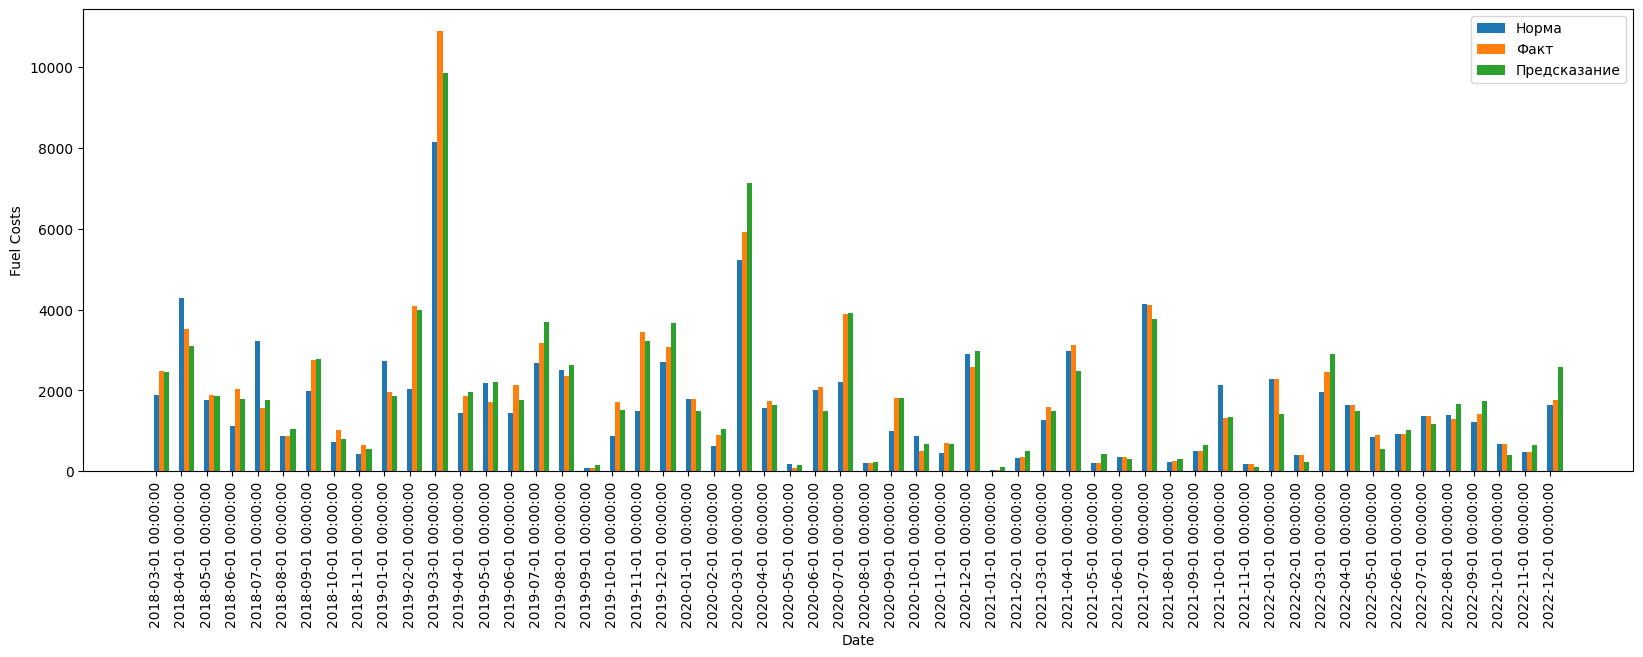

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

dates = fuel_value_group.index
fuel_costs_group1 = fuel_value_group['fuel_normal']
fuel_costs_group2 = fuel_value_group['fuel_fact']
fuel_costs_group3 = fuel_value_group['fuel_predict']

figure(figsize=(20, 6))
plt.bar(range(len(dates)), fuel_costs_group1, width=0.2, align='center', label='Норма')
plt.bar([x + 0.2 for x in range(len(dates))], fuel_costs_group2, width=0.2, align='center', label='Факт')
plt.bar([x + 0.4 for x in range(len(dates))], fuel_costs_group3, width=0.2, align='center', label='Предсказание')

plt.xlabel('Date')
plt.xticks(rotation=90)
plt.ylabel('Fuel Costs')
plt.xticks(range(len(dates)), dates)
plt.legend()

plt.show()

### Импорты файлов

In [ ]:
fuel_rmse.to_csv("fuel_rmse.csv")

In [ ]:
fuel.to_csv("fuel_1326.csv")

In [ ]:
fuel_filtered.to_csv("fuel_filtered.csv")

Дополнительный анализ